# 🔧 Техническое задание: Анализ зависимости между продажами и ключевой ставкой ЦБ РФ

## 📌 Цель

Определить, существует ли зависимость между продажами компании и ключевой ставкой Центрального Банка РФ за 2024 год.

---

## 🗂️ Входные данные

### 1. Таблица с продажами по месяцам (`df_sales`)

Содержит значения выручки компании на каждый месяц.

💡 *Важно*: период с данными по продажам может меняться, скрипт должен быть гибким и не жёстко привязан к конкретному диапазону дат.

```python
dates = pd.date_range(start='2024-01-01', end='2024-12-01', freq='MS').strftime('%Y-%m-%d')

df_sales = pd.DataFrame({
    'date': dates,
    'sales': [5350, 5450, 5500, 4500, 4400, 3900, 3800, 4000, 4500, 4900, 5000, 5500]
})
```

### 2. Ключевая ставка ЦБ РФ
Исторические данные находятся на официальном сайте Банка России:
🔗 https://www.cbr.ru/hd_base/keyrate/

## 📌 **Задачи**
1. Собрать данные о ключевой ставке с сайта ЦБ РФ: подключиться к сайту с ключевой ставкой, спарсить актуальные данные сайта любым доступным способом.
2. Сгруппировать данные по максимальной ключевой ставке за месяц
3. Объединить таблицу продаж (df_sales) и сгруппированную таблицу с ключевой ставкой. 
   В итоге должна получится таблица, состоящая из трех столбцов: date, sales, rate (ключевая ставка)
4. Сделать выводы: имеется ли зависимость между объемом продаж. Для этого можно использовать любой доступный способ (например, визуализация)


## 📈 **Ожидаемые результаты**
1. Ключевая ставка парсится каждый раз при запуске скрипта
2. Имеется итоговая таблица со столбцами date, sales, rate (ключевая ставка) с данными на каждый месяц, при изменении периода в df_sales, ключевая ставка также подтягивается в объединенную таблицу.
3. Сделаны выводы по зависимости объема продаж от ключевой ставки.

# Анализ

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
start_date = '2024-01-01'
end_date = '2024-12-01'
date_format = '%Y-%m-%d'
date_freq = 'MS'
dates = pd.date_range(start=start_date, end=end_date, freq=date_freq).strftime(date_format)
df_sales = pd.DataFrame({
    'date': dates,
    'sales': [5350, 5450, 5500, 4500, 4400, 3900, 3800, 4000, 4500, 4900, 5000, 5500]
})

# Форматирует строку из '%Y-%m-%d' в '%d.%m.%Y'
reformat_string = lambda x: '.'.join(x.split(sep='-')[::-1])

query_from_date = reformat_string(dates[0])
# +1 месяц, чтобы данные за последний тоже попали
query_to_date = reformat_string((pd.Timestamp(dates.values[-1]) + pd.DateOffset(months = 1)).strftime(date_format))
# У сайта ЦБ есть API, но так, на мой взгляд, проще и понятнее
keyrate_link = fr'https://www.cbr.ru/hd_base/keyrate/?UniDbQuery.Posted=True&UniDbQuery.From={query_from_date}&UniDbQuery.To={query_to_date}'

eng_columns = {'Дата': 'date', 'Ставка': 'keyrate'}
df = (
    pd.read_html(keyrate_link, converters = {'Ставка': lambda x: int(x)/100})
    [0]
    .rename(columns=eng_columns)
    .assign(date=lambda x: pd.to_datetime(x['date'], dayfirst=True))
    .groupby(pd.Grouper(freq=date_freq, key='date'))
    .max()
    .reset_index()
    .merge(
        (
            df_sales
            .assign(date=lambda x: pd.to_datetime(x['date']))
        ),
        on='date'
    )
)
df


,date,keyrate
0,2024-01-01,16.0
1,2024-02-01,16.0
2,2024-03-01,16.0
3,2024-04-01,16.0
4,2024-05-01,16.0
5,2024-06-01,16.0
6,2024-07-01,18.0
7,2024-08-01,18.0
8,2024-09-01,19.0
9,2024-10-01,21.0


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     12 non-null     datetime64[ns]
 1   keyrate  12 non-null     float64       
 2   sales    12 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 420.0 bytes


Text(0.5, 1.0, 'Продажи')

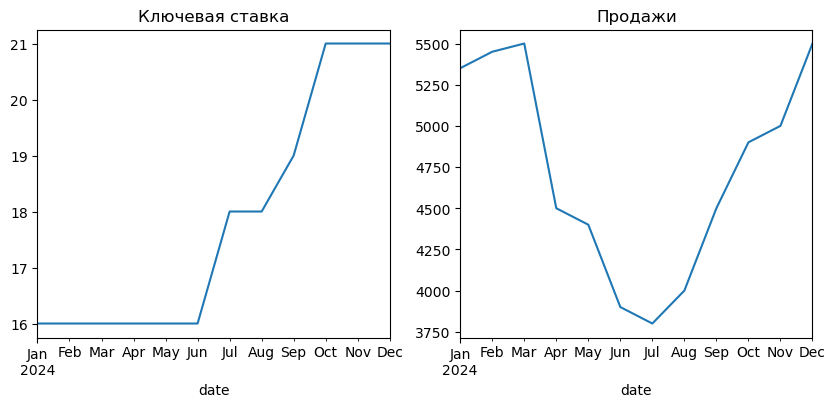

In [101]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
df.plot(kind='line', x='date', y='keyrate', ax = axes[0], legend=False)
df.plot(kind='line', x='date', y='sales', ax = axes[1], legend=False)
axes[0].set_title('Ключевая ставка')
axes[1].set_title('Продажи')

<Axes: >

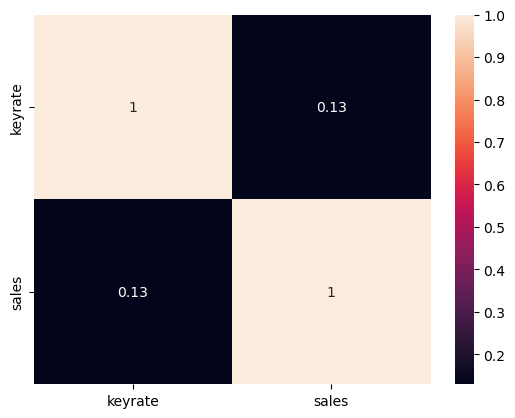

In [100]:
data = df[['keyrate', 'sales']].corr()
sns.heatmap(data, annot=True)

# Вывод

* Исходя из приведенных графиков и рассчитанного коэффицинта корреляции, который составляет 0.13(меньше 0.5), можно заключить, что зависимость между продажами и ключевой ставкой ЦБ РФ **отсутствует**